# Model Selection

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)

In [23]:
df = pd.read_csv("sba_data.csv")
print(df.shape)
df.head()

(520019, 19)


,borrstate,grossapproval,approvalfy,initialinterestrate,fixedorvariableinterestind,terminmonths,projectstate,businesstype,businessage,loanstatus,revolverstatus,jobssupported,collateralind,default,is_franchise,naics_2,is_startup,state_mismatch,borrstate_freq
0,NY,5000.0,2009,7.50,V,144,NY,INDIVIDUAL,"Existing, 5 or more years",P I F,False,5.0,True,0,0,Construction,0,False,0.084322
1,NY,25000.0,2009,7.00,V,84,NY,CORPORATION,Less than 3 years old but at least 2,P I F,True,6.0,False,0,0,Construction,0,False,0.084322
2,CO,495000.0,2009,7.36,V,234,CO,CORPORATION,"Existing, 5 or more years",P I F,False,15.0,True,0,0,Retail,0,False,0.060603
3,MI,25000.0,2009,9.38,F,60,MI,INDIVIDUAL,"Existing, 5 or more years",P I F,False,0.0,False,0,0,Retail,0,False,0.054138
4,AK,12500.0,2009,9.50,V,120,AK,INDIVIDUAL,Less than 5 years old but at least 4,P I F,False,8.0,False,0,0,Retail,0,False,0.057051


In [24]:
df.dtypes

borrstate                         str
grossapproval                 float64
approvalfy                      int64
initialinterestrate           float64
fixedorvariableinterestind        str
terminmonths                    int64
projectstate                      str
businesstype                      str
businessage                       str
loanstatus                        str
revolverstatus                   bool
jobssupported                 float64
collateralind                    bool
default                         int64
is_franchise                    int64
naics_2                           str
is_startup                      int64
state_mismatch                   bool
borrstate_freq                float64
dtype: object

In [25]:
numerical = ["grossapproval", "borrstate_freq", "initialinterestrate", "revolverstatus",
                 "jobssupported", "is_franchise", "is_startup", "state_mismatch"]
categorical = ["naics_2", "businesstype", "fixedorvariableinterestind"]
target = "default"

all_features = numerical + categorical
print(f"Total features: {len(all_features)}")

Total features: 11


## Train/test split

We will be using a temporal split at 2018 which gives us a roughly 80/20 train test split. It is important to have it split in this way because we do not want our model to be learning on 2025 loans to predict on 2010 loans. Loans are time dependent, there's different economic states, and 2018 also is around when they made the documentation change in "Business Age".

In [26]:
train = df[df["approvalfy"] <= 2018]
test = df[df["approvalfy"] > 2018]

X_train = train[all_features]
y_train = train[target]
X_test = test[all_features]
y_test = test[target]

print(f"Train: {X_train.shape} {(X_train.shape[0])/ (X_train.shape[0] + X_test.shape[0]):.2f}%, Default rate: {y_train.mean():.2%}")
print(f"Test: {X_test.shape} {(X_test.shape[0])/ (X_train.shape[0] + X_test.shape[0]):.2f}%, Default rate: {y_test.mean():.2%}")

Train: (422156, 11) 0.81%, Default rate: 7.46%
Test: (97863, 11) 0.19%, Default rate: 8.46%


## Encoders and class imbalance

We will be using a standard sclaer for numerical features and one-hot encoding for categorical features. Only about 8% of loans default. This is like finding a needle in a haystack. But we can't get away with just labelling everything as a non-default. We need to penalize misclassifying the minority class appropriately with the ratio of the classes.

In [27]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical)])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# class imbalance weight
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

scale_pos_weight: 12.40


## Models

We will be working with logistic regression, decision trees, random forest, gradient boosting, XGBoost, and CatBoost classifiers. Our focus will be on PR-AUC which measures model performance with a focus on how well the model identifies the positive class. Unlike ROC-AUC, it is sensitive to class imbalance
and directly reflects the tradeoff between finding defaults and tolerating false alarms.

In [28]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=200, class_weight="balanced", solver="saga", n_jobs=-1, random_state=310),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=310),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", n_jobs=-1, random_state=310),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=310),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric="aucpr", verbose=0, n_jobs=-1, random_state=310),
    "CatBoost": CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, random_state=310)
}

## Model Choice

All six models have similar performance with XGBoost being the best by a slight margin. The gap between a linear model and an ensemble is small enough that it can't be explained by model choice. If the
features contained strong, learnable signal about loan defaults, complex models would find it. The fact that it didn't suggests the ceiling is in the data, not the model choice. We will take the XGBoost model and optimize it to make sure we aren't leaving anything on the table.

In [29]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
    })
    print(f"{name} PR-AUC={results[-1]['PR-AUC']:.4f} ROC-AUC={results[-1]['ROC-AUC']:.4f}")

results_df = (pd.DataFrame(results).set_index("Model").sort_values("PR-AUC", ascending=False))
results_df.round(4)

/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression PR-AUC=0.1996 ROC-AUC=0.7262
DecisionTree PR-AUC=0.1716 ROC-AUC=0.7171
RandomForest PR-AUC=0.1960 ROC-AUC=0.7231
GradientBoosting PR-AUC=0.1695 ROC-AUC=0.7213


/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:14:20] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1784612121784/work/src/learner.cc:793: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost PR-AUC=0.2117 ROC-AUC=0.7396
0:	learn: 0.6849696	total: 30.4ms	remaining: 6.04s
1:	learn: 0.6779903	total: 47.3ms	remaining: 4.69s
2:	learn: 0.6724909	total: 62.8ms	remaining: 4.12s
3:	learn: 0.6682364	total: 78.3ms	remaining: 3.84s
4:	learn: 0.6644479	total: 94.2ms	remaining: 3.67s
5:	learn: 0.6613312	total: 110ms	remaining: 3.56s
6:	learn: 0.6589198	total: 124ms	remaining: 3.43s
7:	learn: 0.6566519	total: 139ms	remaining: 3.34s
8:	learn: 0.6546531	total: 154ms	remaining: 3.28s
9:	learn: 0.6530958	total: 169ms	remaining: 3.2s
10:	learn: 0.6517568	total: 184ms	remaining: 3.15s
11:	learn: 0.6503890	total: 199ms	remaining: 3.11s
12:	learn: 0.6491960	total: 213ms	remaining: 3.07s
13:	learn: 0.6482162	total: 227ms	remaining: 3.02s
14:	learn: 0.6474569	total: 242ms	remaining: 2.99s
15:	learn: 0.6466361	total: 258ms	remaining: 2.96s
16:	learn: 0.6458652	total: 273ms	remaining: 2.93s
17:	learn: 0.6451594	total: 287ms	remaining: 2.9s
18:	learn: 0.6446449	total: 300ms	remaining: 2.85s
1

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost,0.6019,0.1445,0.7530,0.2424,0.7396,0.2117
CatBoost,0.5628,0.1380,0.7945,0.2351,0.7355,0.1998
LogisticRegression,0.5248,0.1301,0.8124,0.2243,0.7262,0.1996
RandomForest,0.5043,0.1245,0.8058,0.2157,0.7231,0.1960
DecisionTree,0.5388,0.1335,0.8109,0.2293,0.7171,0.1716
GradientBoosting,0.9062,0.1647,0.0267,0.0459,0.7213,0.1695


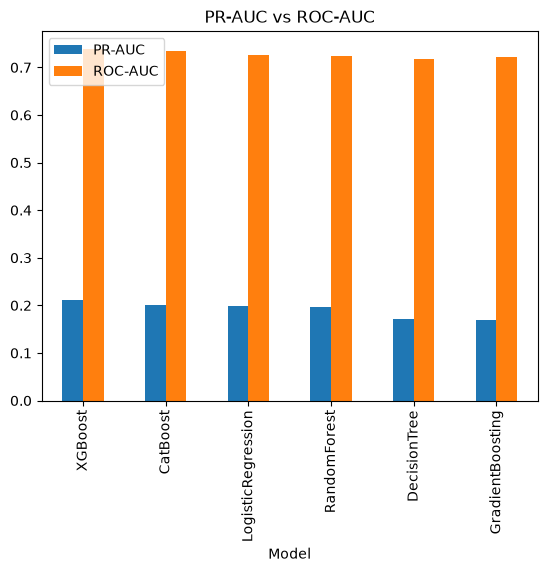

In [30]:
results_df[["PR-AUC", "ROC-AUC"]].plot(kind="bar", title="PR-AUC vs ROC-AUC")
plt.show()

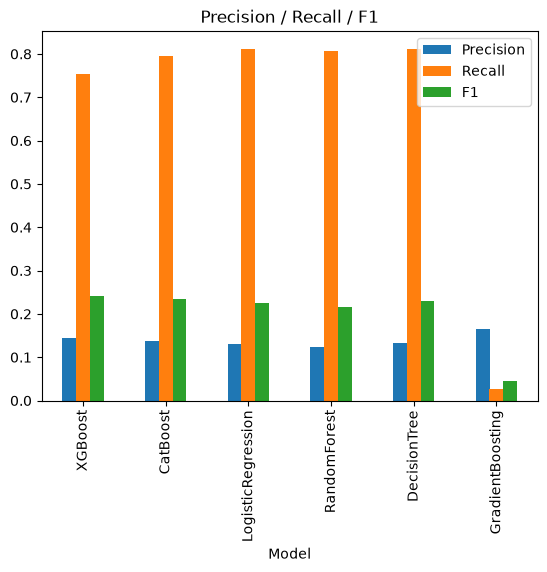

In [31]:
results_df[["Precision", "Recall", "F1"]].plot(kind="bar", title="Precision / Recall / F1")
plt.show()

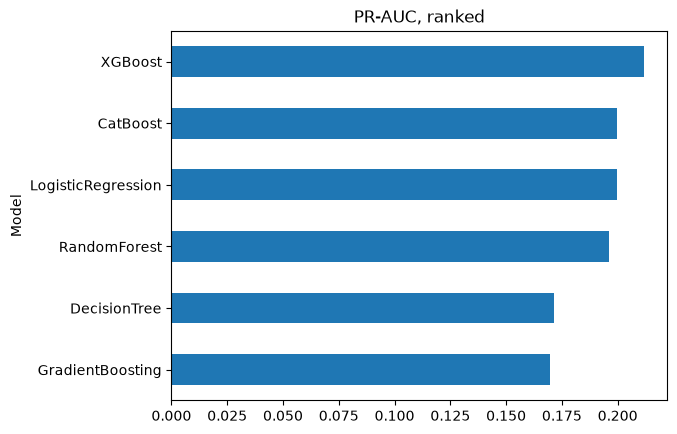

In [32]:
results_df["PR-AUC"].sort_values().plot(kind="barh", title="PR-AUC, ranked")
plt.show()

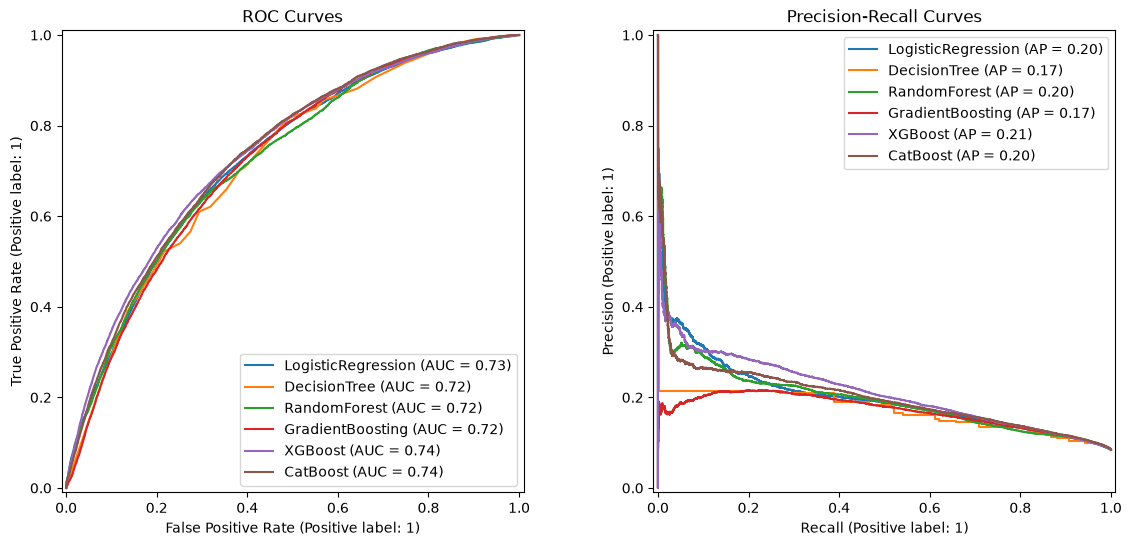

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])

axes[0].set_title("ROC Curves")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right")
plt.show()

## Hyperparameter optimization by grid search

Tested a bunch of versions of the models with different parameters. Take the best combo. Essentially brute force. Cross validation 3fold.

In [34]:
'''
from sklearn.model_selection import GridSearchCV

xgb_model = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos, eval_metric="aucpr", n_jobs=-1, random_state=310,
                        max_depth=5, min_child_weight=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)

param_grid = {
    #"max_depth": [3, 5, 10]
    #"learning_rate": [0.01, 0.1, 0.2]
    #"subsample": [0.8, 1.0]
    #"min_child_weight": [4, 5, 6]
    #"colsample_bytree" : [0.6, 0.8]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring="average_precision", cv=3, n_jobs=1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
'''

'\nfrom sklearn.model_selection import GridSearchCV\n\nxgb_model = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos, eval_metric="aucpr", n_jobs=-1, random_state=310,\n                        max_depth=5, min_child_weight=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)\n\nparam_grid = {\n    #"max_depth": [3, 5, 10]\n    #"learning_rate": [0.01, 0.1, 0.2]\n    #"subsample": [0.8, 1.0]\n    #"min_child_weight": [4, 5, 6]\n    #"colsample_bytree" : [0.6, 0.8]\n}\n\ngrid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring="average_precision", cv=3, n_jobs=1, verbose=1)\ngrid_search.fit(X_train, y_train)\n\nprint(f"Best hyperparameters: {grid_search.best_params_}")\nprint(f"Best CV score: {grid_search.best_score_:.4f}")\n'

## Threshold tuning

Model outputs a probabiltity and if it's over a certain threshold, we label it as a default. It is usually 0.5, but the optimal threshold for an imbalanced problem is rarely 0.5. The cost of a missed default is typically higher than the cost of a false alarm. We will search for the best threshold optimized on PR-AUC.

In [35]:
from sklearn.model_selection import TunedThresholdClassifierCV
model = XGBClassifier(n_estimators=500, scale_pos_weight=scale_pos, eval_metric="aucpr", n_jobs=-1, random_state=310,
                        max_depth=5, min_child_weight=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)

threshold_tuner = TunedThresholdClassifierCV(estimator=model, scoring="average_precision", cv=5)
threshold_tuner.fit(X_train, y_train)

print(f"Optimal threshold: {threshold_tuner.best_threshold_}")

Optimal threshold: 0.5992023348808289


## Results

After parameter and threshold tuning, we improved to model's PR-AUC by 0.01. This is not nothing, but it confirms that the model is not the limiting factor here. 

A random classifier on this dataset would achieve a PR-AUC equal to the base rate: approximately 0.08, since 8% of loans charged off. Our model reaches 0.22, which is roughly 2.7 times the baseline. Our model captures real and meaningful signal. A lender using this model to prioritize high-risk for additional review would surface defaults at nearly three times the rate of random selection.

But 0.22 also means the model is wrong a lot. The remaining gap between 0.22 and anything approaching 1.0 reflects information that simply is not in the feature set. Loan application data tells you who applied and for how much; it does not tell you whether the borrower has a history of missed payments or what their business financial situation looks like.

In [36]:
final_model = XGBClassifier(n_estimators=500, scale_pos_weight=scale_pos, eval_metric="aucpr", n_jobs=-1, random_state=310,
                        max_depth=5, min_child_weight=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)
final_model.fit(X_train, y_train)
prob = final_model.predict_proba(X_test)[:, 1]
pred = (prob >= threshold_tuner.best_threshold_).astype(int)
print("___TUNED___")
print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"Recall: {recall_score(y_test, pred):.4f}")
print(f"F1: {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, prob):.4f}")
prauc_new = average_precision_score(y_test, prob)
print(f"PR-AUC:  {average_precision_score(y_test, prob):.4f}")

og_model = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos, eval_metric="aucpr", n_jobs=-1, random_state=310,
                        max_depth=6, learning_rate=0.1)
og_model.fit(X_train, y_train)
prob = og_model.predict_proba(X_test)[:, 1]
pred = (prob >= threshold_tuner.best_threshold_).astype(int)
print("___ORIGINAL___")
print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"Recall: {recall_score(y_test, pred):.4f}")
print(f"F1: {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, prob):.4f}")
prauc_old = average_precision_score(y_test, prob)
print(f"PR-AUC:  {average_precision_score(y_test, prob):.4f}")

print("_____________")
print(f"Improvement in PR-AUC: {prauc_new - prauc_old:.4f}")

___TUNED___
Accuracy: 0.7388
Precision: 0.1835
Recall: 0.6053
F1: 0.2817
ROC-AUC:  0.7460
PR-AUC:  0.2223
___ORIGINAL___
Accuracy: 0.7377
Precision: 0.1811
Recall: 0.5962
F1: 0.2778
ROC-AUC:  0.7396
PR-AUC:  0.2117
_____________
Improvement in PR-AUC: 0.0106


## Feature importance

Let's see what the model learned from. A lot of the features we derived contributed significant signal. State mismatch is sitting at the top. Start-up and franchise flags sitting around 0.02-0.03. Frequency encoding the borrower states was also good feature. We can get an idea of what industries carry real signal like healthcare, finance, and transportation.

In [37]:
importance_df = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                               Feature  Importance
7                  num__state_mismatch    0.177867
32   cat__fixedorvariableinterestind_V    0.069291
31   cat__fixedorvariableinterestind_F    0.063049
3                  num__revolverstatus    0.059853
2             num__initialinterestrate    0.053089
15            cat__naics_2_Health Care    0.048053
13                cat__naics_2_Finance    0.046264
25         cat__naics_2_Transportation    0.031993
6                      num__is_startup    0.029053
30       cat__businesstype_PARTNERSHIP    0.025672
1                  num__borrstate_freq    0.025601
23            cat__naics_2_Real Estate    0.025173
21  cat__naics_2_Professional Services    0.024747
0                   num__grossapproval    0.022561
24                 cat__naics_2_Retail    0.021818
28       cat__businesstype_CORPORATION    0.020989
5                    num__is_franchise    0.020835
9             cat__naics_2_Agriculture    0.019453
11           cat__naics_2_Const